## Data Probe
Explores the ground water well log dataset for the boardman area
15 townships are included: 
T5N R25E, T5N R26E, T5N R27E, 
T4N R24E, T4N R25E, T4N R26E, T4N R27E, 
T3N R24E, T3N R25E, T3N R26E, T3N R27E,
T2N R24E, T2N R25E, T2N R26E, T2N R27E.

These townships covers the surrounding area (magenta) for the boardman site (red).


<img src="figures/township_boardman.png" width="50%">

In [1]:
import csv
from pathlib import Path
import matplotlib.pyplot as plt

In [4]:
files = sorted(Path("../01_raw/wells").rglob("lithology.csv"))
counts = []
for path in files:
    with path.open(encoding="utf-8-sig", newline="") as f:
        rows = csv.reader(f)
        next(rows, None)  # skip header
        count = sum(any(cell.strip() for cell in row) for row in rows)
    if count:
        counts.append(count)

if not counts:
    raise SystemExit("No lithology data found.")

print(f"Wells with non-empty lithology: {len(counts)}")
print(f"Total lithology files checked: {len(files)}")

Wells with non-empty lithology: 1172
Total lithology files checked: 3306


Histogram saved to: ../05_notebooks/figures/lithology_row_counts.png


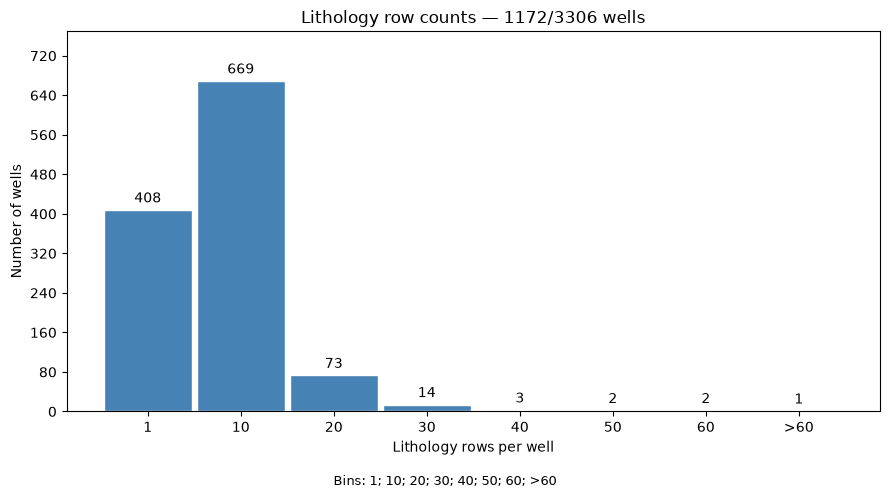

In [5]:
ranges = [(1, 1), (2, 10), (11, 20), (21, 30), (31, 40),
          (41, 50), (51, 60)]
labels = ["1", "10", "20", "30", "40", "50", "60"]
frequencies = [
    sum(low <= count <= high for count in counts)
    for low, high in ranges
]

if max(counts) > 60:
    labels.append(">60")
    frequencies.append(sum(count > 60 for count in counts))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, frequencies, width=0.95,
              color="steelblue", edgecolor="white")

ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel("Lithology rows per well")
ax.set_ylabel("Number of wells")
ax.set_title(f"Lithology row counts — {len(counts)}/{len(files)} wells")
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.margins(y=0.15)
fig.text(0.5, 0.02,
         "Bins: 1; 10; 20; 30; 40; 50; 60; >60",
         ha="center", fontsize=9)
fig.tight_layout(rect=[0, 0.05, 1, 1])

output = Path("../05_notebooks/figures/lithology_row_counts.png")
output.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output, dpi=200)
print(f"Histogram saved to: {output}")
plt.show()

### Extract Lat Lon for wells with lithology rows (including wells with only one row of lithology)

In [ ]:
import json
import csv
from pathlib import Path
wells_dir = Path("../01_raw/wells")
output = Path("../03_processed/wells/well_with_lithology.csv")
records = []

for lithology in sorted(wells_dir.rglob("lithology.csv")):
    with lithology.open(encoding="utf-8-sig", newline="") as f:
        rows = csv.reader(f)
        next(rows, None)
        if not any(any(cell.strip() for cell in row) for row in rows):
            continue

    metadata_path = lithology.parent / "metadata.json"
    if not metadata_path.exists():
        print(f"Skipped {lithology.parent.name}: missing metadata.json")
        continue

    with metadata_path.open(encoding="utf-8") as f:
        metadata = json.load(f)

    records.append({
        "well_number": lithology.parent.name,
        "wl_id": metadata.get("wl_id"),
        "latitude": metadata.get("latitude_dec"),
        "longitude": metadata.get("longitude_dec"),
    })

output.parent.mkdir(parents=True, exist_ok=True)
with output.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(
        f, fieldnames=["well_number", "wl_id", "latitude", "longitude"]
    )
    writer.writeheader()
    writer.writerows(records)

print(f"Saved {len(records)} wells to {output}")

Saved 1172 wells to ../03_processed/wells/well_with_lithology.csv


### Extract Lat Lon for wells with lithology rows (excluding wells with only one row of lithology)

In [8]:
import json
import csv
from pathlib import Path
wells_dir = Path("../01_raw/wells")
output = Path("../03_processed/wells/well_with_lithology_greater_than_one_row.csv")
records = []
for lithology in sorted(wells_dir.rglob("lithology.csv")):
    with lithology.open(encoding="utf-8-sig", newline="") as f:
        rows = csv.reader(f)
        next(rows, None)
        count = sum(any(cell.strip() for cell in row) for row in rows)

    if count <= 1:
        continue

    metadata_path = lithology.parent / "metadata.json"
    if not metadata_path.exists():
        print(f"Skipped {lithology.parent.name}: missing metadata.json")
        continue

    with metadata_path.open(encoding="utf-8") as f:
        metadata = json.load(f)

    records.append({
        "well_number": lithology.parent.name,
        "wl_id": metadata.get("wl_id"),
        "latitude": metadata.get("latitude_dec"),
        "longitude": metadata.get("longitude_dec"),
    })

output.parent.mkdir(parents=True, exist_ok=True)
with output.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(
        f, fieldnames=["well_number", "wl_id", "latitude", "longitude"]
    )
    writer.writeheader()
    writer.writerows(records)

print(f"Saved {len(records)} wells to {output}")

Saved 764 wells to ../03_processed/wells/well_with_lithology_greater_than_one_row.csv
